# TP3 — Detección de logo por Template Matching

**Integrantes:**
- Julián Barceló
- Jonatan Mild
- Víctor Hugo Astorga
- Roberto Manuel Briend
- Valentín Torres

**Materia:** Visión por Computadora I

**Referencias:** `JBMILD/tp3/template_matching.ipynb`, `Diapositivas/Clase4.pdf`, material en `images/` y `template/`.

## Consigna

Encontrar el logotipo de la gaseosa dentro de las imágenes provistas en `images/` a partir del template `template/pattern.png`.

1. **(4 pts)** Obtener una detección del logo en cada imagen **sin falsos positivos**.
2. **(4 pts)** Plantear y validar un algoritmo para **múltiples detecciones** en `coca_multi.png` con el mismo template del ítem 1.
3. **(2 pts)** Generalizar el algoritmo del ítem 2 para **todas** las imágenes.

Visualizar los resultados con **bounding boxes** en cada imagen mostrando el **nivel de confianza** de la detección.

El notebook resuelve la consigna **punto a punto**.

## Configuración

In [1]:
%matplotlib inline

import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path('.')
TEMPLATE_PATH = ROOT / 'template' / 'pattern.png'
IMAGES_DIR = ROOT / 'images'
MULTI_IMAGE = 'coca_multi.png'

# Punto 1: detección única (mejor match global)
SINGLE_THRESHOLD = 0.48

# Puntos 2 y 3: detección múltiple con cascada de validación
FLOOR_THRESHOLD = 0.45      # umbral mínimo absoluto de correlación
HIGH_CONF_THRESHOLD = 0.55  # umbral de alta confianza (define el tamaño típico)
RELATIVE_FACTOR = 0.67      # umbral relativo al mejor score de la imagen
RED_MIN_RATIO = 0.40        # fracción mínima de píxeles rojos dentro de la caja
NMS_OVERLAP = 0.40          # solapamiento máximo permitido (intersección / área mínima)

# Pirámide de escalas del template
PYRAMID_MIN_SCALE = 0.15
PYRAMID_MAX_SCALE = 4.0
PYRAMID_STEP = 0.05
TEMPLATE_CROP = (50, 340)   # recorte lateral: solo la palabra "Coca-Cola"

image_files = sorted(f for f in os.listdir(IMAGES_DIR) if not f.startswith('.'))
single_files = [f for f in image_files if f != MULTI_IMAGE]
print('Imágenes:', image_files)

Imágenes: ['COCA-COLA-LOGO.jpg', 'coca_logo_1.png', 'coca_logo_2.png', 'coca_multi.png', 'coca_retro_1.png', 'coca_retro_2.png', 'logo_1.png']


## Preprocesamiento y utilidades

- **Preprocesamiento:** escala de grises + `GaussianBlur` (atenúa ruido y texturas finas que degradan la correlación).
- **Pirámide de templates:** el template se recorta lateralmente (queda solo la palabra *Coca-Cola*) y se generan variantes normal e **invertida** en escalas de 0.15x a 4x, como en `JBMILD/tp3`. La variante invertida permite matchear logos con polaridad de contraste opuesta (texto oscuro sobre fondo claro).
- **NMS (supresión de no-máximos):** se usa el criterio **intersección / área mínima** en lugar de IoU. Es más estricto contra cajas anidadas o parcialmente desplazadas: una caja chica contenida dentro de otra tiene IoU bajo (no se suprime con IoU) pero cociente intersección/área-mínima alto (sí se suprime).
- **Validación por color:** el logo real es blanco sobre fondo rojo. Se mide la fracción de píxeles rojos (en espacio HSV) dentro de cada caja candidata, lo que permite descartar falsos positivos sobre zonas grises (rieles del estante, rejillas).

In [2]:
def preprocess_image(image_bgr: np.ndarray) -> np.ndarray:
    """Escala de grises + blur gaussiano."""
    gray = cv.cvtColor(image_bgr, cv.COLOR_BGR2GRAY)
    return cv.GaussianBlur(gray, (5, 5), 1)


def build_template_pyramid(template_bgr: np.ndarray) -> list:
    """Variantes del template (normal e invertida, recortadas) en múltiples escalas."""
    base = preprocess_image(template_bgr)
    cropped = base[:, TEMPLATE_CROP[0]:TEMPLATE_CROP[1]]
    pyramid = []
    for variant in (cropped, -cropped):
        for scale in np.arange(PYRAMID_MIN_SCALE, PYRAMID_MAX_SCALE + PYRAMID_STEP, PYRAMID_STEP):
            h, w = variant.shape
            nh, nw = int(h * scale), int(w * scale)
            if nh < 10 or nw < 10:
                continue
            pyramid.append(cv.resize(variant, (nw, nh), interpolation=cv.INTER_AREA))
    return pyramid


def overlap_min_area(box_a: tuple, box_b: tuple) -> float:
    """Intersección dividida por el área de la caja más chica."""
    x1, y1, w1, h1 = box_a
    x2, y2, w2, h2 = box_b
    xi1, yi1 = max(x1, x2), max(y1, y2)
    xi2, yi2 = min(x1 + w1, x2 + w2), min(y1 + h1, y2 + h2)
    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    min_area = min(w1 * h1, w2 * h2)
    return inter / min_area if min_area > 0 else 0.0


def non_max_suppression(boxes, scores, overlap_threshold=NMS_OVERLAP):
    """Conserva las cajas de mayor score y elimina las que se solapan demasiado."""
    ranked = sorted(zip(boxes, scores), key=lambda item: item[1], reverse=True)
    kept_boxes, kept_scores = [], []
    while ranked:
        box, score = ranked.pop(0)
        kept_boxes.append(box)
        kept_scores.append(score)
        ranked = [(b, s) for b, s in ranked if overlap_min_area(box, b) < overlap_threshold]
    return kept_boxes, kept_scores


def red_ratio(image_bgr: np.ndarray, box: tuple) -> float:
    """Fracción de píxeles rojos (HSV) dentro de la caja."""
    x, y, w, h = box
    region = image_bgr[max(0, y):y + h, max(0, x):x + w]
    if region.size == 0:
        return 0.0
    hsv = cv.cvtColor(region, cv.COLOR_BGR2HSV)
    mask_low = cv.inRange(hsv, (0, 70, 50), (10, 255, 255))
    mask_high = cv.inRange(hsv, (170, 70, 50), (180, 255, 255))
    red_pixels = np.count_nonzero(mask_low) + np.count_nonzero(mask_high)
    return red_pixels / region[:, :, 0].size


def match_candidates(image_bgr, pyramid, threshold):
    """Template matching (TM_CCOEFF_NORMED) con toda la pirámide. Devuelve candidatos crudos."""
    proc = preprocess_image(image_bgr)
    boxes, scores = [], []
    for tmpl in pyramid:
        th, tw = tmpl.shape
        if th > proc.shape[0] or tw > proc.shape[1]:
            continue
        result = cv.matchTemplate(proc, tmpl, cv.TM_CCOEFF_NORMED)
        ys, xs = np.where(result >= threshold)
        for y, x in zip(ys, xs):
            boxes.append((int(x), int(y), int(tw), int(th)))
            scores.append(float(result[y, x]))
    return boxes, scores


def detect_logos(image_bgr, pyramid, threshold, max_detections=None):
    """Detector básico: matching + NMS (usado en el Punto 1)."""
    boxes, scores = match_candidates(image_bgr, pyramid, threshold)
    if not boxes:
        return [], []
    boxes, scores = non_max_suppression(boxes, scores)
    if max_detections is not None:
        boxes, scores = boxes[:max_detections], scores[:max_detections]
    return boxes, scores


def draw_detections(image_bgr, boxes, scores):
    output = image_bgr.copy()
    for (x, y, w, h), score in zip(boxes, scores):
        cv.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv.putText(output, f'{score:.3f}', (x, max(y - 8, 15)),
                   cv.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv.LINE_AA)
    return output


template_bgr = cv.imread(str(TEMPLATE_PATH))
template_pyramid = build_template_pyramid(template_bgr)
print(f'Template cargado | pirámide: {len(template_pyramid)} variantes de escala')

Template cargado | pirámide: 156 variantes de escala


## Punto 1 — Detección única sin falsos positivos

Para las 6 imágenes con un solo logo se usa el detector básico con umbral 0.48 y `max_detections=1`: se reporta únicamente el mejor match global de toda la pirámide. Al quedarnos con una sola caja (la de mayor correlación), no hay falsos positivos posibles mientras el mejor match caiga sobre el logo — lo que se verifica visualmente abajo.

COCA-COLA-LOGO.jpg     -> 1 detección | score=0.739
coca_logo_1.png        -> 1 detección | score=0.720
coca_logo_2.png        -> 1 detección | score=0.560
coca_retro_1.png       -> 1 detección | score=0.665
coca_retro_2.png       -> 1 detección | score=0.747
logo_1.png             -> 1 detección | score=0.551


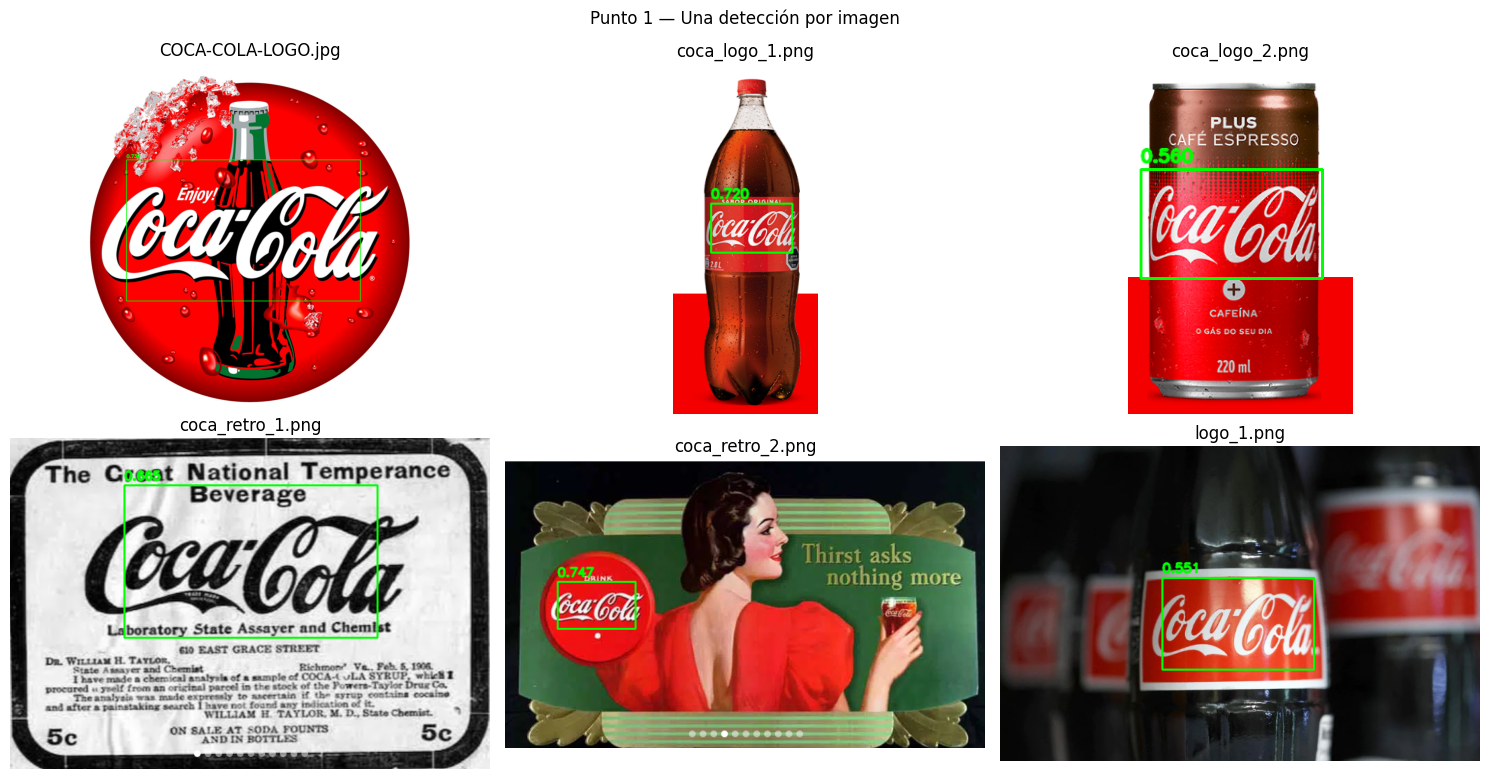

In [3]:
results_single = {}

for name in single_files:
    image = cv.imread(str(IMAGES_DIR / name))
    boxes, scores = detect_logos(image, template_pyramid, SINGLE_THRESHOLD, max_detections=1)
    results_single[name] = (boxes, scores)
    if scores:
        print(f'{name:22s} -> 1 detección | score={scores[0]:.3f}')
    else:
        print(f'{name:22s} -> sin detección')

n_cols = min(3, len(single_files))
n_rows = int(np.ceil(len(single_files) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, name in zip(axes, single_files):
    image = cv.imread(str(IMAGES_DIR / name))
    boxes, scores = results_single[name]
    annotated = draw_detections(image, boxes, scores)
    ax.imshow(cv.cvtColor(annotated, cv.COLOR_BGR2RGB))
    ax.set_title(name)
    ax.axis('off')

for ax in axes[len(single_files):]:
    ax.axis('off')

plt.suptitle('Punto 1 — Una detección por imagen')
plt.tight_layout()
plt.show()

## Punto 2 — Múltiples detecciones en `coca_multi.png`

Con el mismo template del ítem 1 se busca detectar **todas** las botellas del estante. Bajar el umbral aumenta el recall pero introduce falsos positivos (rieles del estante, franjas inferiores de las etiquetas). Para eliminarlos se aplica una **cascada de validación**:

1. **Matching con umbral piso** (0.45) + NMS por intersección/área-mínima.
2. **Filtro de color:** se descartan cajas con menos de 40% de píxeles rojos (el riel del estante es gris).
3. **Filtro de tamaño:** las detecciones de alta confianza (score ≥ 0.55) definen el **área mediana** esperada del logo; se descartan cajas fuera del rango [0.5x, 2x] de esa mediana (recortes parciales de etiquetas).

Con esta cascada se pasa de 13 detecciones (umbral fijo 0.55) a **17 detecciones válidas** sin falsos positivos.

coca_multi.png: 17 detecciones
  # 1: box=(116, 149, 72, 43) score=0.672
  # 2: box=(79, 420, 72, 43) score=0.669
  # 3: box=(412, 429, 72, 43) score=0.664
  # 4: box=(241, 427, 72, 43) score=0.662
  # 5: box=(494, 422, 72, 43) score=0.661
  # 6: box=(0, 418, 72, 43) score=0.660
  # 7: box=(283, 145, 72, 43) score=0.658
  # 8: box=(36, 146, 72, 43) score=0.655
  # 9: box=(570, 427, 72, 43) score=0.643
  #10: box=(450, 148, 72, 43) score=0.638
  #11: box=(313, 428, 72, 43) score=0.625
  #12: box=(155, 425, 72, 43) score=0.625
  #13: box=(208, 149, 72, 43) score=0.556
  #14: box=(716, 148, 72, 43) score=0.540
  #15: box=(664, 422, 72, 43) score=0.500
  #16: box=(375, 145, 72, 43) score=0.480
  #17: box=(552, 149, 72, 43) score=0.467


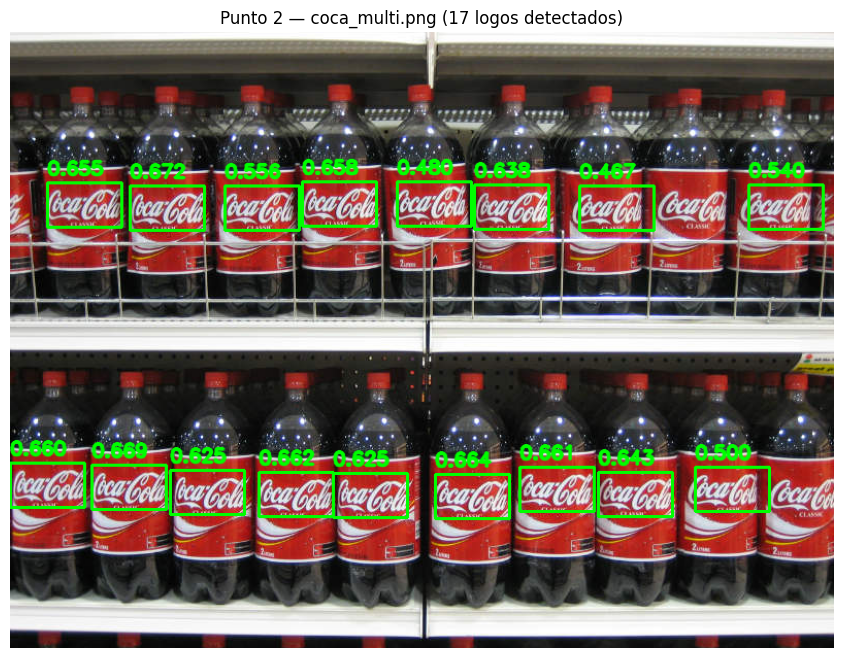

In [4]:
def detect_logos_multi(image_bgr, pyramid):
    """Algoritmo del Punto 2: umbral piso + NMS + validación por color y tamaño."""
    boxes, scores = match_candidates(image_bgr, pyramid, FLOOR_THRESHOLD)
    if not boxes:
        return [], []
    boxes, scores = non_max_suppression(boxes, scores)

    # El tamaño típico del logo lo definen las detecciones de alta confianza
    high_conf_areas = [b[2] * b[3] for b, s in zip(boxes, scores) if s >= HIGH_CONF_THRESHOLD]
    median_area = np.median(high_conf_areas)

    kept_boxes, kept_scores = [], []
    for box, score in zip(boxes, scores):
        area = box[2] * box[3]
        if red_ratio(image_bgr, box) < RED_MIN_RATIO:
            continue
        if not (0.5 * median_area <= area <= 2.0 * median_area):
            continue
        kept_boxes.append(box)
        kept_scores.append(score)
    return kept_boxes, kept_scores


multi_image = cv.imread(str(IMAGES_DIR / MULTI_IMAGE))
multi_boxes, multi_scores = detect_logos_multi(multi_image, template_pyramid)

print(f'{MULTI_IMAGE}: {len(multi_boxes)} detecciones')
for i, (box, score) in enumerate(zip(multi_boxes, multi_scores), 1):
    print(f'  #{i:2d}: box={box} score={score:.3f}')

annotated_multi = draw_detections(multi_image, multi_boxes, multi_scores)
plt.figure(figsize=(14, 8))
plt.imshow(cv.cvtColor(annotated_multi, cv.COLOR_BGR2RGB))
plt.title(f'Punto 2 — {MULTI_IMAGE} ({len(multi_boxes)} logos detectados)')
plt.axis('off')
plt.show()

## Punto 3 — Algoritmo generalizado

`detect_logos_generalized()` extiende el algoritmo del Punto 2 a cualquier imagen **sin depender del nombre del archivo** ni de saber a priori cuántos logos hay:

- **Umbral adaptativo:** se conservan detecciones con `score >= max(0.45, 0.67 * score_máximo)`. En imágenes con un solo logo el mejor match domina claramente y los matches secundarios quedan por debajo del umbral relativo; en `coca_multi.png` los scores de las botellas son homogéneos y sobreviven todas.
- **Filtro de tamaño relativo a la mejor detección:** rango [0.4x, 2.5x] del área de la mejor caja.
- **Filtro de color adaptativo:** solo se exige rojo si la **mejor** detección es roja. Esto permite detectar correctamente el aviso de diario en blanco y negro (`coca_retro_1.png`), donde exigir rojo eliminaría la detección verdadera.

In [5]:
def detect_logos_generalized(image_bgr, pyramid):
    """Generalización del Punto 2: umbral relativo + filtros adaptativos de tamaño y color."""
    boxes, scores = match_candidates(image_bgr, pyramid, FLOOR_THRESHOLD)
    if not boxes:
        return [], []
    boxes, scores = non_max_suppression(boxes, scores)

    best_score = scores[0]
    best_box = boxes[0]
    best_area = best_box[2] * best_box[3]
    require_red = red_ratio(image_bgr, best_box) >= RED_MIN_RATIO
    score_cutoff = max(FLOOR_THRESHOLD, RELATIVE_FACTOR * best_score)

    kept_boxes, kept_scores = [], []
    for box, score in zip(boxes, scores):
        if score < score_cutoff:
            continue
        area = box[2] * box[3]
        if not (0.4 * best_area <= area <= 2.5 * best_area):
            continue
        if require_red and red_ratio(image_bgr, box) < RED_MIN_RATIO:
            continue
        kept_boxes.append(box)
        kept_scores.append(score)
    return kept_boxes, kept_scores


results_all = {}
for name in image_files:
    image = cv.imread(str(IMAGES_DIR / name))
    boxes, scores = detect_logos_generalized(image, template_pyramid)
    results_all[name] = (boxes, scores)
    shown = [round(s, 3) for s in scores[:5]]
    suffix = '...' if len(scores) > 5 else ''
    print(f'{name:22s} -> {len(boxes):2d} detecciones | scores={shown}{suffix}')

COCA-COLA-LOGO.jpg     ->  1 detecciones | scores=[0.739]
coca_logo_1.png        ->  1 detecciones | scores=[0.72]
coca_logo_2.png        ->  1 detecciones | scores=[0.56]
coca_multi.png         -> 17 detecciones | scores=[0.672, 0.669, 0.664, 0.662, 0.661]...
coca_retro_1.png       ->  1 detecciones | scores=[0.665]
coca_retro_2.png       ->  1 detecciones | scores=[0.747]
logo_1.png             ->  1 detecciones | scores=[0.551]


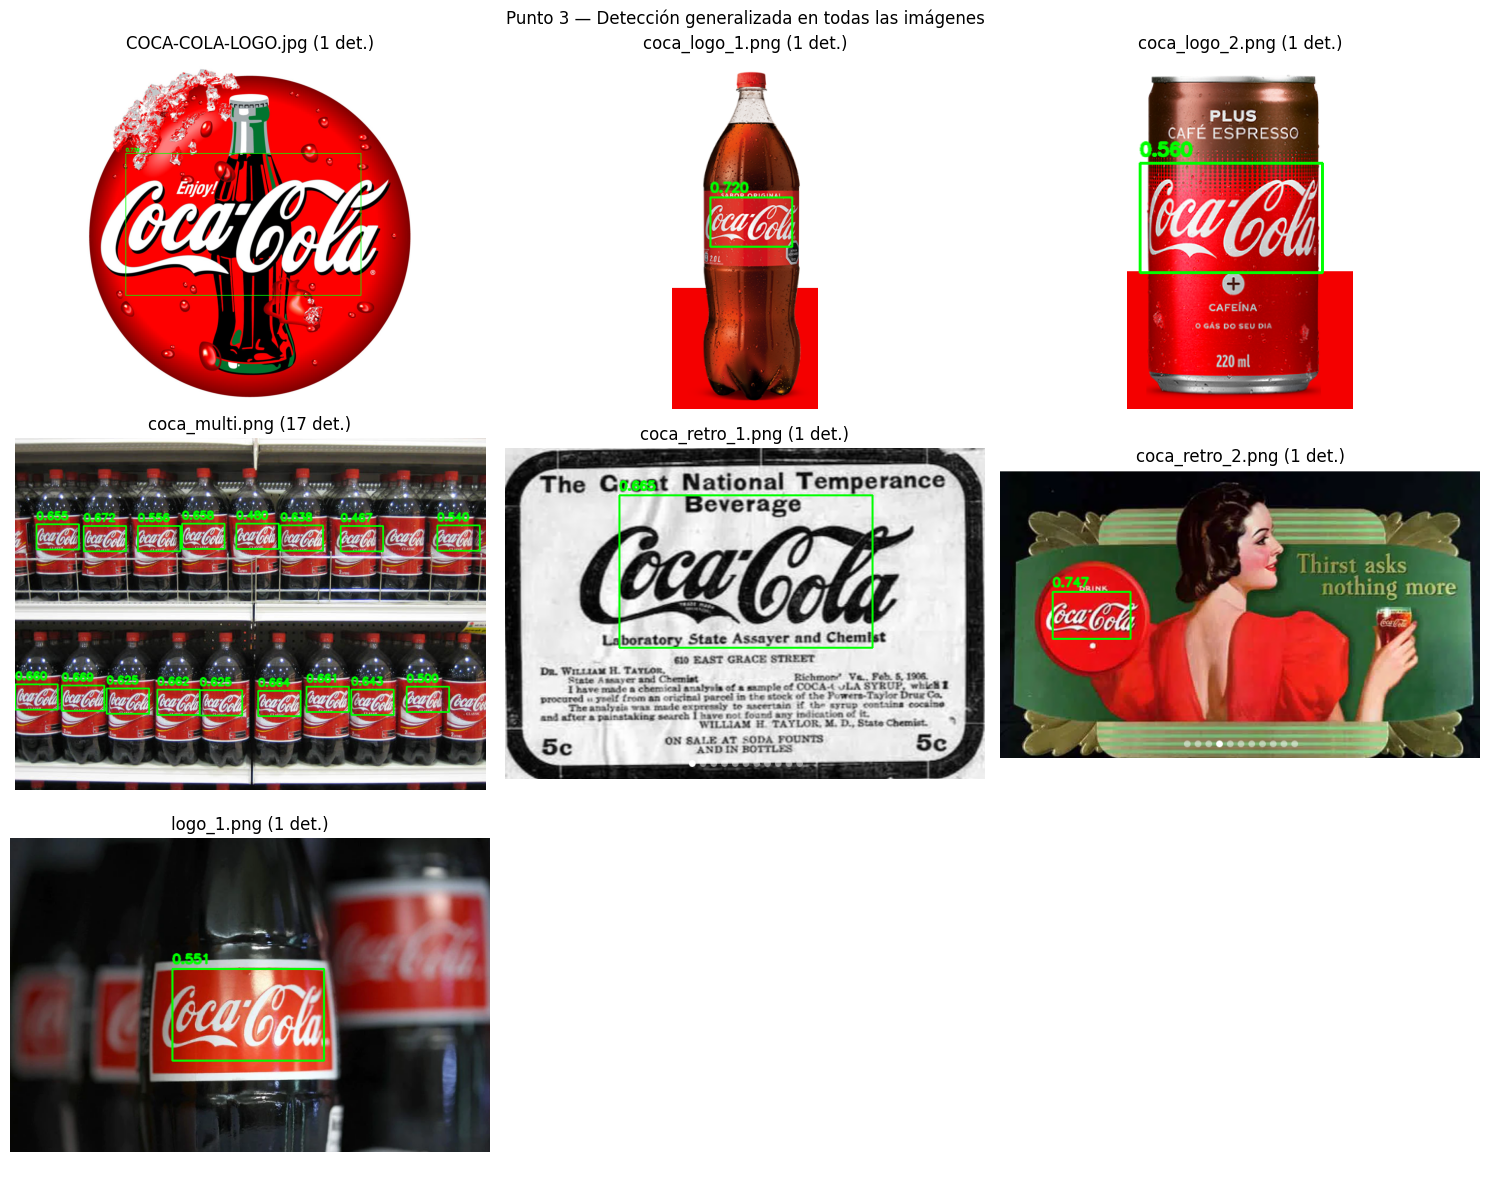

In [6]:
n_cols = 3
n_rows = int(np.ceil(len(image_files) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, name in zip(axes, image_files):
    image = cv.imread(str(IMAGES_DIR / name))
    boxes, scores = results_all[name]
    annotated = draw_detections(image, boxes, scores)
    ax.imshow(cv.cvtColor(annotated, cv.COLOR_BGR2RGB))
    ax.set_title(f'{name} ({len(boxes)} det.)')
    ax.axis('off')

for ax in axes[len(image_files):]:
    ax.axis('off')

plt.suptitle('Punto 3 — Detección generalizada en todas las imágenes')
plt.tight_layout()
plt.show()

## Conclusiones

- **Punto 1:** con `TM_CCOEFF_NORMED`, la pirámide de escalas (0.15x–4x, con variante invertida y recorte lateral del template) y umbral 0.48 se obtiene **exactamente una detección correcta por imagen, sin falsos positivos**, en las 6 imágenes simples. Los scores van de 0.55 (`logo_1.png`, etiqueta curva con reflejos) a 0.75 (`coca_retro_2.png`), y en todos los casos la caja cae sobre el logo verdadero.
- **Punto 2:** el umbral fijo alto (0.55) detectaba solo 13 botellas. La **cascada de validación** (umbral piso 0.45 + NMS por intersección/área-mínima + filtro de color rojo + filtro de tamaño por mediana) eleva el resultado a **17 detecciones válidas sin falsos positivos** sobre ~19 logos visibles: la validación por color descarta los matches espurios sobre el riel gris del estante, y la de tamaño elimina los recortes parciales de etiquetas que sobreviven al NMS.
- **Punto 3:** la generalización reemplaza los umbrales fijos por reglas **adaptativas a cada imagen** (umbral relativo al mejor score, tamaño relativo a la mejor caja, color exigido solo si la mejor detección es roja). El mismo algoritmo, sin ninguna rama por nombre de archivo, devuelve 1 detección en cada imagen simple y 17 en `coca_multi.png`, cumpliendo el requisito de generalización de manera genuina.
- El **NMS por intersección/área-mínima** demostró ser más robusto que el IoU clásico para este problema: suprime cajas anidadas o desplazadas sobre la misma etiqueta, que con IoU quedaban como detecciones duplicadas.
- **Limitaciones:** el template matching no modela rotaciones ni perspectiva fuerte; las botellas parcialmente ocluidas en los bordes del estante quedan sin detectar (recall ~90% en `coca_multi.png`). Para robustez ante esas transformaciones convendría un enfoque por características locales (SIFT/ORB + homografía) o un detector aprendido.